In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('../datasets/wine_data.csv')

In [34]:
df.shape

(177, 14)

In [35]:
num_cols = df.select_dtypes(include='number').columns

In [36]:
num_cols

Index(['1', '14.23', '1.71', '2.43', '15.6', '127', '2.8', '3.06', '.28',
       '2.29', '5.64', '1.04', '3.92', '1065'],
      dtype='object')

In [37]:
df[num_cols].skew().abs().sort_values()

1.04     0.026964
3.06     0.036880
14.23    0.046483
2.8      0.097688
1        0.097941
2.43     0.172406
15.6     0.204076
3.92     0.320424
.28      0.440937
2.29     0.532787
1065     0.783800
5.64     0.870850
1.71     1.030975
127      1.122148
dtype: float64

<Axes: xlabel='15.6', ylabel='Count'>

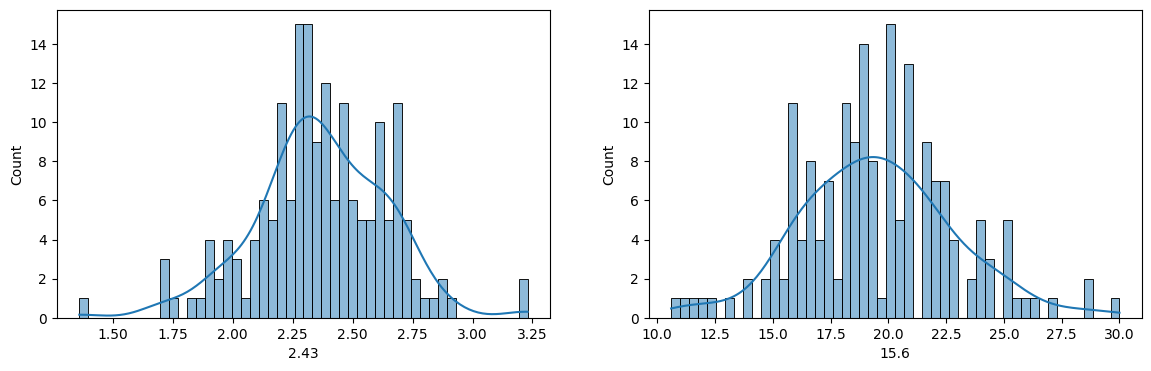

In [48]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df['2.43'],bins=50,kde=True)
plt.subplot(122)
sns.histplot(df['15.6'],bins=50,kde=True)

In [50]:
df['15.6'].describe()

count    177.000000
mean      19.516949
std        3.336071
min       10.600000
25%       17.200000
50%       19.500000
75%       21.500000
max       30.000000
Name: 15.6, dtype: float64

## We can only apply this z score method on normally distributed bell curves

In [54]:
highest_allowed = (df['15.6'].mean() + 3*df['15.6'].std())
lowest_allowed = (df['15.6'].mean() - 3*df['15.6'].std())

In [52]:
highest_allowed

np.float64(29.52516236290608)

In [55]:
lowest_allowed

np.float64(9.508735942178667)

In [58]:
df[(df['15.6'] > highest_allowed) | (df['15.6'] < lowest_allowed)]

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
72,2,12.99,1.67,2.6,30.0,139,3.3,2.89,0.21,1.96,3.35,1.31,3.5,985


# Trimming

In [61]:
new_df = df[(df['15.6'] < highest_allowed) & (df['15.6'] > lowest_allowed)]
new_df

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


# Capping

In [64]:
df['15.6'] = np.where(
    df['15.6']>highest_allowed,
    highest_allowed,
    np.where(
        df['15.6']<lowest_allowed,
        lowest_allowed,
        df['15.6']
    )
)

In [65]:
df.shape

(177, 14)

In [ ]:
df['15.6'].describe()
# Replaces the outliner with max

count    177.000000
mean      19.514266
std        3.327774
min       10.600000
25%       17.200000
50%       19.500000
75%       21.500000
max       29.525162
Name: 15.6, dtype: float64